# Optimization for high c-index simulations
Use systematic parameter optimization (optuna) to generated dataset with high maximum c-index and low censoring




In [1]:
import numpy
import pandas
from survfram.adapters import *
import seaborn
#from survfram.metrics import concordance_td
#from survhive.metrics import concordance_index_antolini_scorer

## Implementations

### Survhive

In [2]:
# code from survhive.metrics

import sksurv.metrics
def get_indicator(y):
    "Get censoring indicator (bool)"
    return y[y.dtype.names[0]]

def get_time(y):
    "Get the time of the event"
    return y[y.dtype.names[1]]

def _estimate_concordance_index_antolini(
    event_indicator, event_time, estimate, weights, tied_tol=0.0,
):
    # taken from sksurv.metrics, generalized to a time-dependant estimate matrix
    # not meant to be called directly but through the concordance_index_td_scorer,
    # since it only works if estimate has the y times as its second index

    order = numpy.argsort(event_time)

    tied_time = None

    concordant = 0
    discordant = 0
    tied_risk = 0
    numerator = 0.0
    denominator = 0.0
    for ind, mask, tied_time in sksurv.metrics._iter_comparable(
        event_indicator, event_time, order
    ):
        est_i = estimate[order[ind], order[ind]]
        event_i = event_indicator[order[ind]]
        w_i = weights[order[ind]]

        est = estimate[order[mask], order[ind]]

        assert (
            event_i
        ), f"got censored sample at index {order[ind]}, but expected uncensored"

        ties = numpy.absolute(est - est_i) <= tied_tol
        n_ties = ties.sum()
        # an event should have a higher score
        con = est < est_i
        n_con = con[~ties].sum()

        numerator += w_i * n_con + 0.5 * w_i * n_ties
        denominator += w_i * mask.sum()

        tied_risk += n_ties
        concordant += n_con
        discordant += est.size - n_con - n_ties

    if tied_time is None:
        raise sksurv.exceptions.NoComparablePairException(
            "Data has no comparable pairs, cannot estimate concordance index."
        )

    cindex = numerator / denominator
    return cindex, concordant, discordant, tied_risk, tied_time, numerator, denominator


def concordance_index_antolini_scorer(estimator, X, y, return_all=False):
    """Antolini's extension of concordance index to time-dependent predictions.

    Implementation based on scikit-survival concordance_index_censored code.

    Parameters:
    - estimator: estimator object with a `predict_survival` method,
    - X: feature matrix for the `predict_survival` method
    - y: survival outcomes for evaluating the prediction
    - return_all: bool, set to true to return more information on the score

    Returns:
    - the concordance score (float) if return_all is false or a tuple (score: float, concordant: int, discordant: int, tied_risk: int, tied_time: int). For more information see scikit-survival concordance_index_censored documentation.
    """

    r = _estimate_concordance_index_antolini(
        event_indicator=get_indicator(y),
        event_time=get_time(y),
        estimate=1.0 - estimator.predict_survival(X, get_time(y)),  # use failure
        weights=numpy.full(len(y), 1.0),
    )
    return r if return_all else r[0]
    

In [3]:
def survhive_anto(est_sq, y, return_all=False):
    assert est_sq.shape == (len(y), len(y)), f"estimator matrix has wrong shape {est_sq.shape} != ({len(y)}, {len(y)})"
    r = _estimate_concordance_index_antolini(
        event_indicator=get_indicator(y),
        event_time=get_time(y),
        estimate=1.0 - est_sq,
        weights=numpy.full(len(y), 1.0),
    )
    cindex, concordant, discordant, tied_risk, tied_time, numerator, denominator = r

    if return_all:
        return {
            'cindex': cindex,
            'concordant': concordant,
            'discordant': discordant,
            'tied_risk': tied_risk,
            'tied_time': tied_time,
            'numerator': numerator,
            'comparable': denominator,
        }
    else:
        return cindex

### Pycox

In [4]:
### Code adapted from Pycox implementation (https://github.com/havakv/pycox/tree/master/pycox/evaluation/concordance.py) ###

import numpy as np

def _is_comparable(t_i, t_j, d_i, d_j):
    return ((t_i < t_j) & d_i) | ((t_i == t_j) & (d_i | d_j))

def _is_comparable_antolini(t_i, t_j, d_i, d_j):
    return ((t_i < t_j) & d_i) | ((t_i == t_j) & d_i & (d_j == 0))

def _is_concordant(s_i, s_j, t_i, t_j, d_i, d_j):
    conc = 0.
    if t_i < t_j:
        conc = (s_i < s_j) + (s_i == s_j) * 0.5
    elif t_i == t_j: 
        if d_i & d_j:
            conc = 1. - (s_i != s_j) * 0.5
        elif d_i:
            conc = (s_i < s_j) + (s_i == s_j) * 0.5  # different from RSF paper.
        elif d_j:
            conc = (s_i > s_j) + (s_i == s_j) * 0.5  # different from RSF paper.
    return conc * _is_comparable(t_i, t_j, d_i, d_j)

def _is_concordant_antolini(s_i, s_j, t_i, t_j, d_i, d_j):
    return (s_i < s_j) & _is_comparable_antolini(t_i, t_j, d_i, d_j)

def _sum_comparable(t, d, is_comparable_func):
    n = t.shape[0]
    count = 0.
    for i in range(n):
        for j in range(n):
            if j != i:
                count += is_comparable_func(t[i], t[j], d[i], d[j])
    return count

def _sum_concordant_disc(s, t, d, s_idx, is_concordant_func):
    n = len(t)
    count = 0
    for i in range(n):
        idx = s_idx[i]
        for j in range(n):
            if j != i:
                count += is_concordant_func(s[idx, i], s[idx, j], t[i], t[j], d[i], d[j])
    return count

def concordance_td(durations, events, surv, surv_idx, method='adj_antolini', return_all=False):
    """Time dependent concorance index from
    Antolini, L.; Boracchi, P.; and Biganzoli, E. 2005. A timedependent discrimination
    index for survival data. Statistics in Medicine 24:3927–3944.

    If 'method' is 'antolini', the concordance from Antolini et al. is computed.
    
    If 'method' is 'adj_antolini' (default) we have made a small modifications
    for ties in predictions and event times.
    We have followed step 3. in Sec 5.1. in Random Survial Forests paper, except for the last
    point with "T_i = T_j, but not both are deaths", as that doesn't make much sense.
    See '_is_concordant'.

    Arguments:
        durations {np.array[n]} -- Event times (or censoring times.)
        events {np.array[n]} -- Event indicators (0 is censoring).
        surv {np.array[n_times, n]} -- Survival function (each row is a duration, and each col
            is an individual).
        surv_idx {np.array[n_test]} -- Mapping of survival_func s.t. 'surv_idx[i]' gives index in
            'surv' corresponding to the event time of individual 'i'.

    Keyword Arguments:
        method {str} -- Type of c-index 'antolini' or 'adj_antolini' (default {'adj_antolini'}).

    Returns:
        float -- Time dependent concordance index.
    """
    if np.isfortran(surv):
        surv = np.array(surv, order='C')
    assert durations.shape[0] == surv.shape[1] == surv_idx.shape[0] == events.shape[0]
    assert type(durations) is type(events) is type(surv) is type(surv_idx) is np.ndarray
    if events.dtype in ('float', 'float32'):
        events = events.astype('int32')
    if method == 'adj_antolini':
        is_concordant = _is_concordant
        is_comparable = _is_comparable
        #return (_sum_concordant_disc(surv, durations, events, surv_idx, is_concordant) /
        #        _sum_comparable(durations, events, is_comparable))
    elif method == 'antolini':
        is_concordant = _is_concordant_antolini
        is_comparable = _is_comparable_antolini
        #return (_sum_concordant_disc(surv, durations, events, surv_idx, is_concordant) /
        #        _sum_comparable(durations, events, is_comparable))
    else:
        return ValueError(f"Need 'method' to be e.g. 'antolini', got '{method}'.")
    n_concordant = _sum_concordant_disc(surv, durations, events, surv_idx, is_concordant)
    n_comparable = _sum_comparable(durations, events, is_comparable)
    cindex = n_concordant / n_comparable
    if return_all:
        return {
            'cindex': cindex,
            'numerator': n_concordant,
            'comparable': n_comparable
        }
    else:
        return cindex

In [5]:
# adapters
def pycox_anto(est_sq, y, method, return_all=False):
    #indexes = numpy.arange(est_sq.shape[1]) + numpy.cumsum(~y['event'])
    indexes = numpy.arange(est_sq.shape[0])
    return concordance_td(y['time'], y['event'], est_sq.T, indexes, method=method, return_all=return_all)

### Sum of sksurv

In [6]:
# questo deve essere proprio sbagliato, non usare
from sksurv.metrics import concordance_index_censored

if False:
    def sksurv_anto(est, y, return_all=False):
        ind = get_indicator(y)
        time = get_time(y)
        assert est.shape == (len(y), ind.sum()), f"estimator matrix has wrong shape {est.shape} != ({len(y)}, {ind.sum()})"
        print(est.shape)
        concordant = 0
        discorant = 0
        tied_risk = 0
        tied_time = 0
        for est_t in est.T:
            cindex_, concordant_, discordant_, tied_risk_, tied_time_ = concordance_index_censored(ind, time, est_t, tied_tol=0.0)
            print(est_t.shape, concordant_)
            concordant += concordant_
            discorant += discordant_
            tied_risk += tied_risk_
            tied_time += tied_time_
        comparable = concordant + discorant + tied_risk + tied_time
        cindex = (concordant + 0.5 * tied_risk) / comparable
        if return_all:
            return cindex, concordant, comparable, tied_risk, tied_time
        else:
            return cindex
    #sksurv_anto(F_sim, y_sim, return_all=True)

### My vectorial

In [7]:
event = numpy.array([False, True, False, True, True, False])
numpy.arange(event.sum()) + (~event).cumsum()[event]


array([1, 3, 4])

In [8]:
numpy.eye(5)[numpy.array([1, 3]), numpy.array([1, 3])]

array([1., 1.])

In [9]:

def test_risk_sets(y):
    event, time = y['event'], y['time']
    time_t = time.reshape(-1, 1) # trasposed times
    e_time = time[event] # event times
    #inv_eye = numpy.eye(len(event), len(e_time)) == 0

    event_idx = numpy.arange(event.sum()) + (~event).cumsum()[event]

    risk_sets_all = (time_t >= e_time)
    risk_sets_all[event_idx, numpy.arange(len(e_time))] = False

    risk_sets_cens = (time_t > e_time) | ((time_t == e_time) & ~event.reshape(-1, 1))
    risk_sets_cens[event_idx, numpy.arange(len(e_time))] = False

    risk_sets_none = time_t > e_time

    diffs = (risk_sets_all != risk_sets_cens) | (risk_sets_all != risk_sets_none) | (risk_sets_cens != risk_sets_none)
    print(y)
    print('event_idx')
    print(event_idx)
    print('all')
    print(risk_sets_all)
    print('cens')
    print(risk_sets_cens)
    print('none')
    print(risk_sets_none)
    print('diffs')
    print(diffs)
 
 
#my_risk_sets(random_surv(5, round=1)[1])

In [10]:
def c_index_anto_scorer(model, X, y, return_all=False):
    est = model.predict('failure', X, y['time'][y['event']])
    return c_index_anto(est, y, return_all=return_all)

def c_index_anto(est, y, time_ties='none', tie_weight=0.5, return_all=False):
    '''time_ties: include time ties in the risk sets'''
    event, time = y['event'], y['time']
    assert event.dtype == numpy.bool
    n_events = event.sum()

    if est.shape[1] == len(time):
        est = est[:,event]

    assert est.shape == (len(time), n_events)


    self_idx = (
        numpy.arange(event.sum()) + (~event).cumsum()[event], 
        numpy.arange(n_events),
    )

    # compute risk sets

    time_t = time.reshape(-1, 1) # trasposed times
    e_time = time[event] # event times
    if time_ties == 'all' or time_ties == 'censored':

        if time_ties == 'censored':
            risk_sets = (time_t > e_time) | ((time_t == e_time) & ~event.reshape(-1, 1))
        elif time_ties == 'all':
            risk_sets = time_t >= e_time
        
        # remove self-comparisons from risk set
        risk_sets[*self_idx] = False
    elif time_ties == 'none':
        risk_sets = time_t > e_time
    else:
        raise ValueError(f"Invalid time_ties '{time_ties}'")

    assert risk_sets.shape == est.shape, f'{risk_sets.shape=} != {est.shape=}'
    #print(time_ties)
    #print(y)
    #print(risk_sets)
    #print(est)

    # compute concordant pairs
    diag_events = est[*self_idx]
    assert all(diag_events == numpy.diag(est[event]))
    concordant = risk_sets * (
        (est > diag_events) + (est == diag_events) * tie_weight
    )
    concordant = risk_sets * (est > diag_events)
    ties = risk_sets * (est == diag_events)

    n_comparable = risk_sets.sum()
    n_concordant = concordant.sum()
    n_ties = ties.sum()

    num = n_concordant + n_ties * tie_weight
    c_index = num / n_comparable
    if return_all:
        return {
            'cindex': c_index, 
            'concordant': n_concordant, 
            'comparable': n_comparable, 
            'tied_risk': n_ties, # check that is the same order as survhive and sksurv cindex
            'numerator': num,
        }
    else:
        return c_index

#test_all_anto(*random_surv(5, round=1), return_all=True)
#test_all_anto(F_sim_sq, y_sim, return_all=True).sort_values('cindex')
#c_index_anto_scorer(m, X_sim, y_sim, return_all=True)

In [11]:
if False: #pycox
    def _is_comparable(t_i, t_j, d_i, d_j):
        return ((t_i < t_j) & d_i) | ((t_i == t_j) & (d_i | d_j))

    def _is_comparable_antolini(t_i, t_j, d_i, d_j):
        return ((t_i < t_j) & d_i) | ((t_i == t_j) & d_i & (d_j == 0))

def comparable_pairs(y):
    t = get_time(y)
    d = get_indicator(y)
    n = len(y)
    all_cmp = 0
    strict_cmp = 0
    sksurv_cmp = 0
    tied_times = 0
    for i in range(n):
        if d[i]:
            for j in range(n):
                if j == i:
                    continue
                if t[j] >= t[i]:
                    all_cmp += 1
                if t[j] > t[i] or ((t[j] == t[i]) and not d[j]):
                    sksurv_cmp += 1
                if t[j] > t[i]:
                    strict_cmp += 1
                if t[j] == t[i]:
                    tied_times += 1
    return all_cmp, strict_cmp, sksurv_cmp, tied_times

## Tests

In [29]:
X = numpy.random.normal(size=(200, 2))
m = SurvivalSimulator(
    input=LinearFunctionInputAdapter(multiplier=1.0),
    #survival=PHSurvAdapter(StepExpSurvAdapter(breaks=3, trainable_breaks=False)),
    survival=WeibullSurvivalAdapter(),
)
y_sim = m.simulate(X, numpy.linspace(0, 1, 1001))
F_sim = m.predict('failure', X, y_sim['time'][y_sim['event']])
F_sim_sq = m.predict('failure', X, y_sim['time'])

In [30]:
F_sim_sq.shape, y_sim.shape, y_sim['event'].mean()

((200, 200), (200,), np.float64(0.735))

In [31]:
len(numpy.unique(y_sim['time'])) / len(y_sim)

0.625

In [32]:
len(numpy.unique(F_sim)) / F_sim.size

0.8355442176870749

In [33]:
comparable_pairs(y_sim)

(18570, 18474, 18474, 96)

### Simulation test

In [40]:
def test_all_anto(est_sq, y, return_all=False):
    est = est_sq[:, y['event']]
    r = {
        'pycox_adj_anto_sq': pycox_anto(1.0 - est_sq, y, 'adj_antolini', return_all=return_all),
        'pycox_anto_sq': pycox_anto(1.0 - est_sq, y, 'antolini', return_all=return_all),
        'survhive_anto': survhive_anto(1.0 - est_sq, y, return_all=return_all),
        'vec_anto_all_ties': c_index_anto(1.0 - est, y, time_ties='all', return_all=return_all),
        'vec_anto_cens_ties': c_index_anto(1.0 - est, y, time_ties='censored', return_all=return_all),
        'vec_anto_no_ties': c_index_anto(1.0 - est, y, time_ties='none', return_all=return_all),
    }
    if return_all:
        df = pandas.DataFrame.from_dict(r, orient='index')
        #df['tied_risk_num'] + df['tied_risk'] * 0.5
        return df
    else:
        return pandas.Series(r)
test_all_anto(F_sim_sq, y_sim, return_all=True).sort_values('comparable')

,cindex,numerator,comparable,concordant,discordant,tied_risk,tied_time
pycox_anto_sq,0.568583,10504.0,18474.0,NaN,NaN,NaN,NaN
survhive_anto,0.610155,11272.0,18474.0,10504.0,6434.0,1536.0,0.0
vec_anto_no_ties,0.610155,11272.0,18474.0,10504.0,NaN,1536.0,NaN
vec_anto_cens_ties,0.610155,11272.0,18474.0,10504.0,NaN,1536.0,NaN
vec_anto_all_ties,0.609585,11320.0,18570.0,10524.0,NaN,1592.0,NaN
pycox_adj_anto_sq,0.611093,11348.0,18570.0,NaN,NaN,NaN,NaN


In [35]:
%timeit c_index_anto(F_sim, y_sim)

336 μs ± 4.35 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [36]:
%time pycox_anto(F_sim_sq, y_sim, 'adj_antolini')

CPU times: user 163 ms, sys: 4.05 ms, total: 167 ms
Wall time: 163 ms


np.float64(0.39192245557350563)

In [37]:
%timeit survhive_anto(F_sim_sq, y_sim)

4.1 ms ± 23.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [21]:
def make_y(tuple_list):
    return numpy.array(tuple_list, dtype=[('event', '?'), ('time', 'f8')])

In [22]:
def random_surv(n_samples, round=2, censor_ratio=0.33, drop_time_ties=False):
    est_sq = numpy.round(numpy.random.rand(n_samples, n_samples), round)
    risk_sq = numpy.cumsum(est_sq, axis=1)
    risk_sq /= risk_sq.max()
    
    time = numpy.round(numpy.random.rand(n_samples), round)
    event = numpy.random.rand(n_samples) >= censor_ratio

    keep = numpy.ones(n_samples, dtype=bool)

    if drop_time_ties:
        utimes = set()
        for i, t in enumerate(time):
            if t in utimes:
                keep[i] = False
            else:
                utimes.add(t)

    y = numpy.array(list(zip(event, time)), dtype=[('event', '?'), ('time', 'f8')])

    risk_sq = risk_sq[keep][:, keep]
    y = y[keep]

    assert risk_sq.shape == (len(y), len(y)), f"risk_sq has wrong shape {risk_sq.shape} != ({len(y)}, {len(y)})"
    return risk_sq, y
    #return risk_sq, y
#random_surv(20, 1, drop_time_ties=True)


In [23]:
def compute_mae(df):
    return pandas.DataFrame({
    i1 : {
        i2: numpy.abs(df[i1] - df[i2]).mean()
        for i2 in df.columns
    }
    for i1 in df.columns
})

### Mini test

In [25]:
test_all_anto(*random_surv(5), return_all=True)

,cindex,numerator,comparable,concordant,discordant,tied_risk,tied_time
pycox_adj_anto_sq,0.0,0.0,2.0,NaN,NaN,NaN,NaN
pycox_anto_sq,0.0,0.0,2.0,NaN,NaN,NaN,NaN
survhive_anto,0.0,0.0,2.0,0.0,2.0,0.0,0.0
vec_anto_all_ties,0.0,0.0,2.0,0.0,NaN,0.0,NaN
vec_anto_cens_ties,0.0,0.0,2.0,0.0,NaN,0.0,NaN
vec_anto_no_ties,0.0,0.0,2.0,0.0,NaN,0.0,NaN


In [26]:
def random_batch_test(n_tests, n_samples, **kwargs):
    return pandas.concat({
        i: test_all_anto(*random_surv(n_samples, **kwargs), return_all=True)
        for i in range(n_tests)
    }, names=['test', 'impl'])
#random_batch_test(100, 20, drop_time_ties=True)

### Random batch test

/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


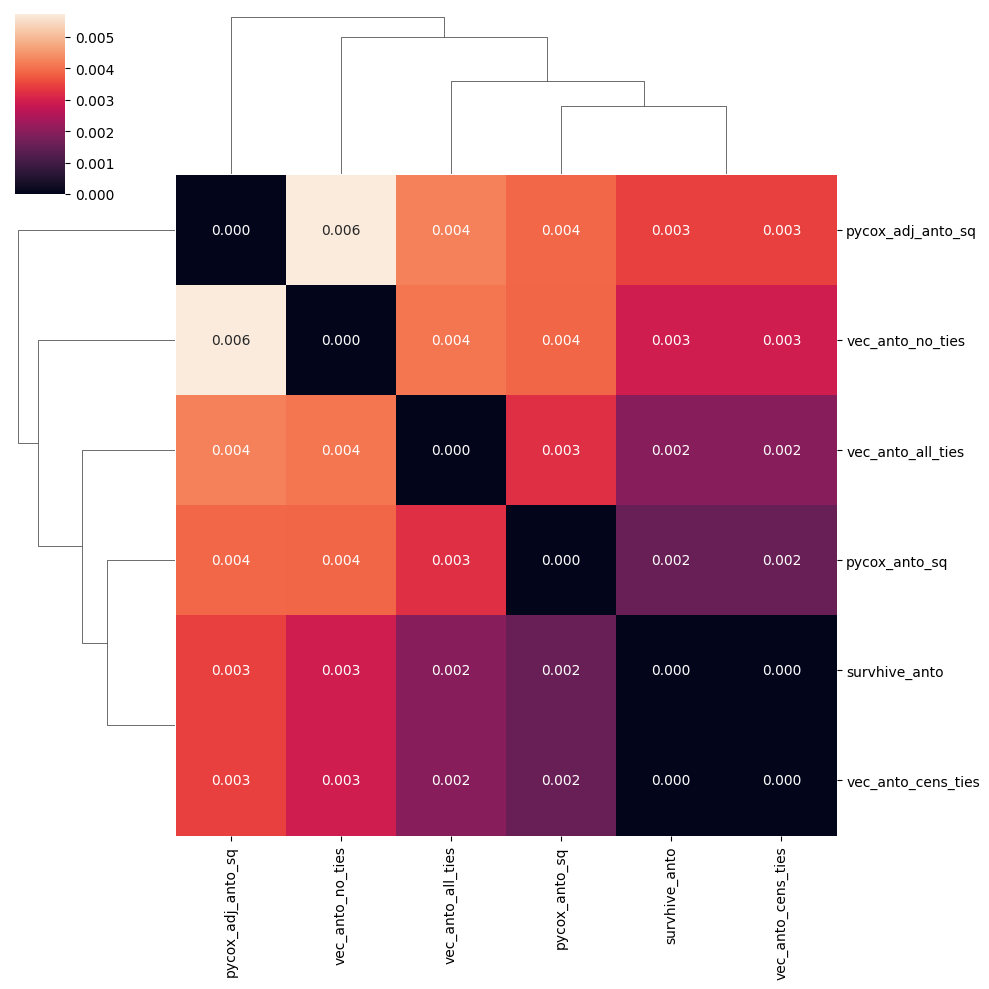

In [38]:
random_ties_results_df = random_batch_test(100, 20, drop_time_ties=False)
#seaborn.clustermap(random_ties_results_df['cindex'].unstack('impl'), annot=True, fmt=".3f")
seaborn.clustermap(compute_mae(random_ties_results_df['cindex'].unstack('impl')), annot=True, fmt=".3f")
#compute_mae(random_ties_results_df['cindex'].unstack('impl'))

/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)
/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/gbirolo/venv/lib/python3.12/site-packages/seaborn/matrix.py:623: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_dependent_coord * 1.05)


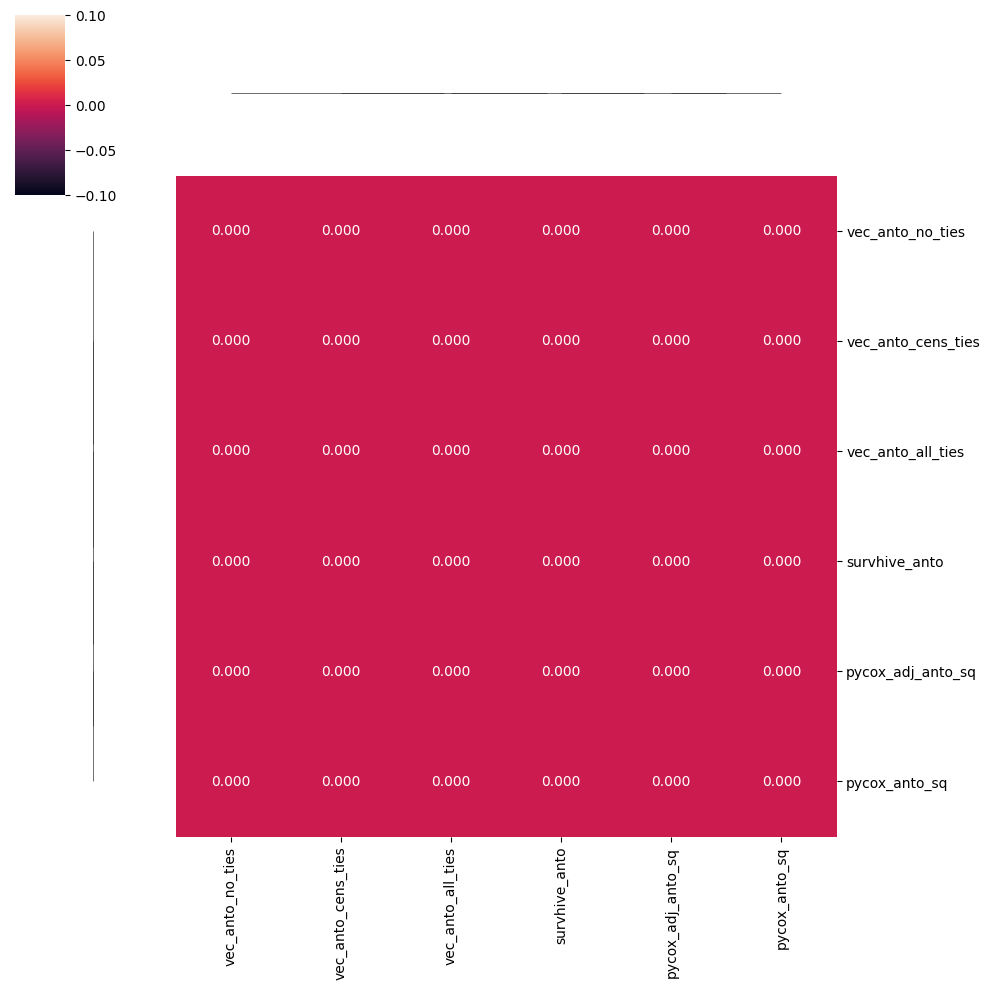

In [39]:
random_noties_results_df = random_batch_test(100, 20, round=10, drop_time_ties=True)
seaborn.clustermap(compute_mae(random_noties_results_df['cindex'].unstack('impl')), annot=True, fmt=".3f")
#seaborn.clustermap(random_noties_results_df['cindex'].unstack('impl'), annot=True, fmt=".3f")
#compute_mae(random_noties_results_df['cindex'].unstack('impl'))

In [24]:
# compute differences of columns
df = r['cindex'].unstack('impl')


NameError: name 'r' is not defined

In [141]:
def mini_random_test():
    est_sq, y = random_surv(4, 1)
    display(est_sq)
    display(y)
    return test_all_anto(est_sq, y, return_all=True)
mini_random_test()

array([[0.4, 0.4, 0.1, 0.3],
       [0.4, 0.1, 0.2, 0.1],
       [0.6, 0.9, 1. , 0.1],
       [0.6, 0.5, 0.4, 0.6]])

array([(False, 0.4), ( True, 0.6), ( True, 0.8), (False, 0.8)],
      dtype=[('event', '?'), ('time', '<f8')])

,cindex,numerator,comparable,concordant,discordant,tied_risk,tied_time
pycox_adj_anto_sq,0.250000,1.0,4.0,NaN,NaN,NaN,NaN
pycox_anto_sq,0.333333,1.0,3.0,NaN,NaN,NaN,NaN
survhive_anto,0.333333,1.0,3.0,1.0,2.0,0.0,1.0
vec_anto_all_ties,0.428571,3.0,7.0,2.0,NaN,2.0,NaN
vec_anto_cens_ties,0.333333,1.0,3.0,1.0,NaN,0.0,NaN
vec_anto_no_ties,0.000000,0.0,2.0,0.0,NaN,0.0,NaN


: 

: 

In [144]:
from tqdm import tqdm
#test_ys = [
#    [(1, 0.1), (1, 0.9), (0, 0.2), (0, 1.2)],
#]

def test_ys(n, r, n_tests=100):
    acc = []
    for _ in tqdm(range(n_tests)):
        est_sq, y = random_surv(n, r)
        acc.append(test_all_anto(est_sq, y, return_all=False))
    return pandas.DataFrame(acc)

noties_tests_df = test_ys(30, 20, 100)
noties_tests_df

100%|██████████| 100/100 [00:01<00:00, 99.45it/s]


,pycox_adj_anto_sq,pycox_anto_sq,survhive_anto,vec_anto_all_ties,vec_anto_cens_ties,vec_anto_no_ties
0,0.418803,0.418803,0.418803,0.430502,0.418803,0.418803
1,0.611570,0.611570,0.611570,0.600760,0.611570,0.611570
2,0.439689,0.439689,0.439689,0.450178,0.439689,0.439689
3,0.364929,0.364929,0.364929,0.365217,0.364929,0.364929
4,0.641256,0.641256,0.641256,0.631579,0.641256,0.641256
...,...,...,...,...,...,...
95,0.356164,0.356164,0.356164,0.365145,0.356164,0.356164
96,0.629630,0.629630,0.629630,0.620968,0.629630,0.629630
97,0.427907,0.427907,0.427907,0.432900,0.427907,0.427907
98,0.581731,0.581731,0.581731,0.577922,0.581731,0.581731


: 

: 

In [145]:
noties_tests_df.mean()

pycox_adj_anto_sq     0.525183
pycox_anto_sq         0.525183
survhive_anto         0.525183
vec_anto_all_ties     0.522555
vec_anto_cens_ties    0.525183
vec_anto_no_ties      0.525183
dtype: float64

: 

: 

In [69]:
from tqdm import tqdm
#test_ys = [
#    [(1, 0.1), (1, 0.9), (0, 0.2), (0, 1.2)],
#]

def test_ys(ys):
    acc = []
    for y in tqdm(ys):
        est_sq = numpy.round(numpy.random.rand(len(y), len(y)), 2)
        acc.append(test_all_anto(est_sq, make_y(y), return_all=False))
    return pandas.DataFrame(acc)

tests_df = test_ys(random_y(100) for _ in range(100))
tests_df

100it [00:09, 10.54it/s]


,0
0,None
1,None
2,None
3,None
4,None
...,...
95,None
96,None
97,None
98,None


: 

: 

In [70]:
tests_df.mean()

0    NaN
dtype: object

: 

: 

ValueError: The condensed distance matrix must contain only finite values.

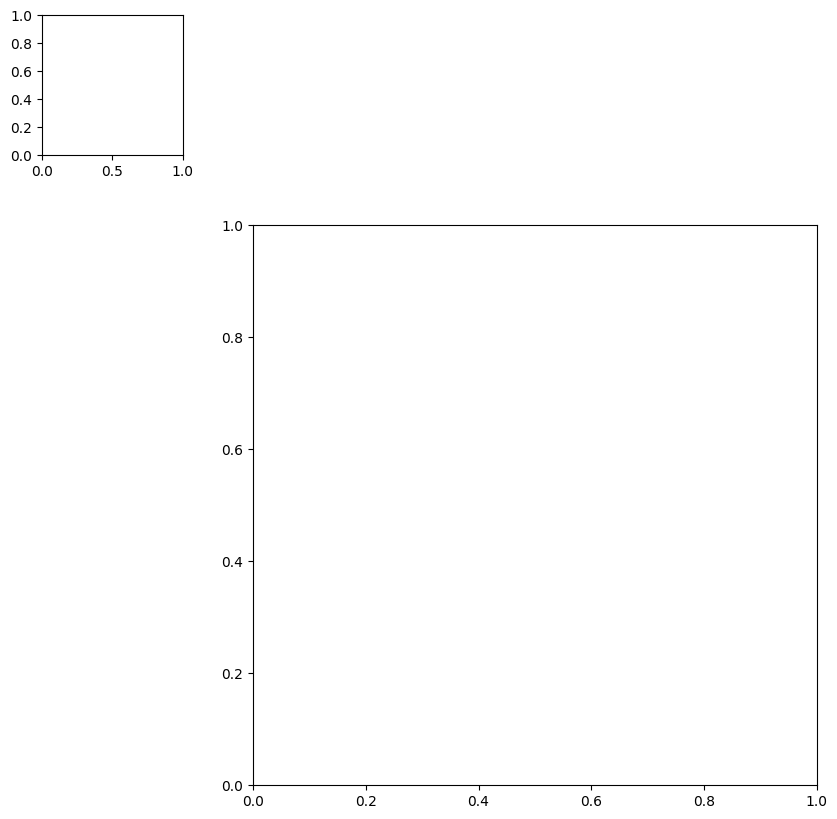

: 

: 

In [71]:
seaborn.clustermap(tests_df)

,pycox_adj_anto_sq,pycox_anto_sq,survhive_anto,vec_anto
pycox_adj_anto_sq,1.000000,0.999546,0.999784,0.999216
pycox_anto_sq,0.999546,1.000000,0.999793,0.999397
survhive_anto,0.999784,0.999793,1.000000,0.999553
vec_anto,0.999216,0.999397,0.999553,1.000000


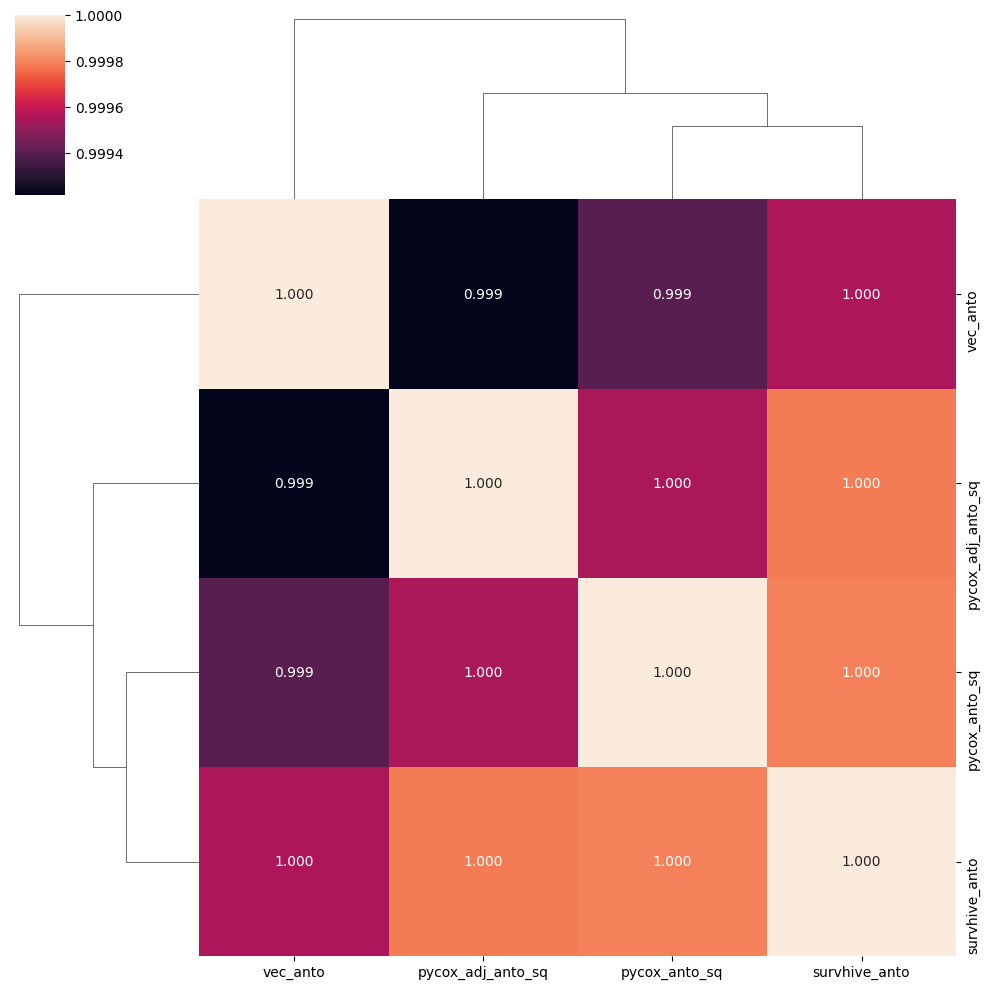

: 

: 

In [119]:
seaborn.clustermap(tests_df.corr(), annot=True, fmt='.3f')
tests_df.corr()

In [120]:
# vectorial implementation of likelihood as reference

def likelihood_vec(model, x, event, time, epsilon):
    risk_sets = time.unsqueeze(-1) >= time[event]
    keep = risk_sets.sum(dim=0) > 1
        
    log_hazard = safe_log(model("hazard", x, time[event]), epsilon)
    top = torch.diag(log_hazard[event])[keep]

    def log_sum_exp(x):
        max_x = torch.max(x, dim=0)[0]
        return max_x + torch.log(torch.sum(torch.exp(x - max_x), dim=0))
    
    bot = log_sum_exp(log_hazard)[keep] #torch.logsumexp(log_hazard, dim=0)[keep]
    log_lh = top - bot
    
    # Check for NaN or Inf values
    if torch.isnan(log_lh).any() or torch.isinf(log_lh).any():
        print("Warning: NaN or Inf values in log-likelihood computation")
        log_lh = torch.where(torch.isfinite(log_lh), log_lh, torch.tensor(0.0, device=log_lh.device))
    
    return -torch.sum(log_lh)



: 

: 